# Challenge 3 · Resultados reproducibles

## Simulación de materiales para dispositivos de energía de próxima generación

Este notebook reúne, ordena y reproduce el núcleo técnico desarrollado para el
**Modelo de Ising con Campo Transverso (TFIM)**. La narrativa sigue el formato
educativo del repositorio de referencia: contexto breve, herramienta utilizada,
resultado gráfico e interpretación física.

**Pregunta central.** ¿Una evolución Suzuki–Trotter de primer orden reproduce la
dinámica y los observables del TFIM frente a diagonalización exacta (ED), y cómo
cambian el error y el costo al aumentar el tamaño?

> Alcance honesto: todos los resultados principales se obtienen en simulación
> ideal sin ruido. No se afirma ventaja cuántica ni ejecución en hardware H2.

## Ruta de lectura

1. Configuración reproducible y herramientas.
2. Hamiltoniano, observables y circuito de Trotter.
3. Línea base clásica por diagonalización exacta.
4. Dinámica para $h/J\in\{0.5,1.0,2.0\}$.
5. Error de Trotter al reducir $\Delta t$.
6. Escalado para $N=4,6,8$.
7. Extensión opcional Fermi–Hubbard 1D.
8. Limitaciones, ODS y lista de verificación.

In [1]:
from importlib.util import find_spec
from IPython.display import Markdown, display
import platform
import numpy as np
import matplotlib
import qiskit

from Funciones import *

estilo_resultados()
np.set_printoptions(precision=5, suppress=True)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Qiskit:", qiskit.__version__)

Python: 3.10.19
NumPy: 2.2.6
Matplotlib: 3.10.8
Qiskit: 2.3.0


## 1. Configuración reproducible

Usamos $J=1$ como unidad de energía y, por tanto, $Jt$ como tiempo
adimensional. La cadena es **periódica** y el estado inicial de la dinámica es
$|00\cdots0\rangle$. La línea base solicitada se reporta para $N=8$; la
comparación dinámica usa $N=6$, tal como pide el planteamiento del reto.

In [2]:
J = 1.0
PERIODIC = True
N_BASELINE = 8
N_DINAMICA = 6
RAZONES_RETO = (0.5, 1.0, 2.0)
TIEMPOS = np.linspace(0.0, 3.0, 31)
PASOS_TROTTER = 60

print({
    "J": J,
    "frontera_periodica": PERIODIC,
    "N_linea_base": N_BASELINE,
    "N_dinamica": N_DINAMICA,
    "h/J": RAZONES_RETO,
    "r": PASOS_TROTTER,
    "dt_max": TIEMPOS[-1] / PASOS_TROTTER,
})

{'J': 1.0, 'frontera_periodica': True, 'N_linea_base': 8, 'N_dinamica': 6, 'h/J': (0.5, 1.0, 2.0), 'r': 60, 'dt_max': np.float64(0.05)}


## 2. Fundamento científico

El TFIM de una dimensión se escribe

$$
H=-J\sum_{\langle i,j\rangle}Z_iZ_j-h\sum_iX_i.
$$

El término $ZZ$ favorece orden ferromagnético; el campo transversal introduce
fluctuaciones cuánticas. En el límite termodinámico, ambos compiten alrededor
de $h/J=1$. En una cadena finita la transición aparece redondeada: por eso no
interpretamos una curva suave como un fallo del modelo.

La evolución exacta $U(t)=e^{-iHt}$ se aproxima a primer orden mediante

$$
U(t)\approx\left[
e^{-iH_X\Delta t}e^{-iH_{ZZ}\Delta t}
\right]^r,\qquad \Delta t=t/r.
$$

Los observables son

$$
M_z=\frac1N\sum_i Z_i,\quad
M_x=\frac1N\sum_i X_i,\quad
C_{zz}=\frac1{N_b}\sum_{\langle i,j\rangle}Z_iZ_j.
$$

Para el estado base finito también usamos $\langle M_z^2\rangle$: la simetría
global puede forzar $\langle M_z\rangle\approx0$ aun cuando exista orden
longitudinal.

### Herramientas

- **Qiskit:** operadores de Pauli, circuitos `RZZ`/`RX` y vectores de estado.
- **NumPy:** diagonalización hermitiana y álgebra lineal.
- **Matplotlib:** figuras reproducibles mediante auxiliares de `Funciones.py`.
- **PennyLane y Guppy:** implementaciones opcionales preservadas en módulos
  separados; no son dependencias del núcleo reproducible.

In [3]:
H_ejemplo = hamiltoniano_tfim(J=J, h=1.0, n_q=4, periodic=PERIODIC)
circuito_ejemplo = circuito_trotter_tfim(
    J=J, h=1.0, n_q=4, r=2, t=0.4, periodic=PERIODIC
)

print("Hamiltoniano de ejemplo (N=4):")
print(H_ejemplo)
print("\nUn circuito de dos pasos:")
print(circuito_ejemplo.draw(output="text", fold=110))
print("\nRecursos:", {
    "profundidad": circuito_ejemplo.depth(),
    "compuertas": circuito_ejemplo.size(),
    "conteo": dict(circuito_ejemplo.count_ops()),
})

Hamiltoniano de ejemplo (N=4):
SparsePauliOp(['IIZZ', 'IZZI', 'ZZII', 'ZIIZ', 'IIIX', 'IIXI', 'IXII', 'XIII'],
              coeffs=[-1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j])

Un circuito de dos pasos:
                                                  ┌──────────┐                                             »
q_0: ─■─────────────────────────────────■─────────┤ Rx(-0.4) ├─■─────────────────────────────────■─────────»
      │ZZ(-0.4)            ┌──────────┐ │         └──────────┘ │ZZ(-0.4)            ┌──────────┐ │         »
q_1: ─■──────────■─────────┤ Rx(-0.4) ├─┼──────────────────────■──────────■─────────┤ Rx(-0.4) ├─┼─────────»
                 │ZZ(-0.4) └──────────┘ │         ┌──────────┐            │ZZ(-0.4) └──────────┘ │         »
q_2: ────────────■──────────■───────────┼─────────┤ Rx(-0.4) ├────────────■──────────■───────────┼─────────»
                            │ZZ(-0.4)   │ZZ(-0.4) ├──────────┤                       │ZZ(-0.4)   │ZZ(-0.4) »
q_3:

## 3. Línea base clásica: estado fundamental por ED

Primero diagonalizamos exactamente cadenas de $N=8$ y barremos el campo. Esta
es la referencia ideal contra la que deben juzgarse las aproximaciones
cuánticas para la misma instancia.

(<Figure size 1540x451 with 3 Axes>,
 array([<Axes: title={'left': 'Orden longitudinal'}, xlabel='$h/J$', ylabel='$\\langle M_z^2\\rangle$'>,
        <Axes: title={'left': 'Respuesta transversal'}, xlabel='$h/J$', ylabel='$\\langle M_x\\rangle$'>,
        <Axes: title={'left': 'Correlación vecina'}, xlabel='$h/J$', ylabel='$\\langle C_{zz}\\rangle$'>],
       dtype=object))

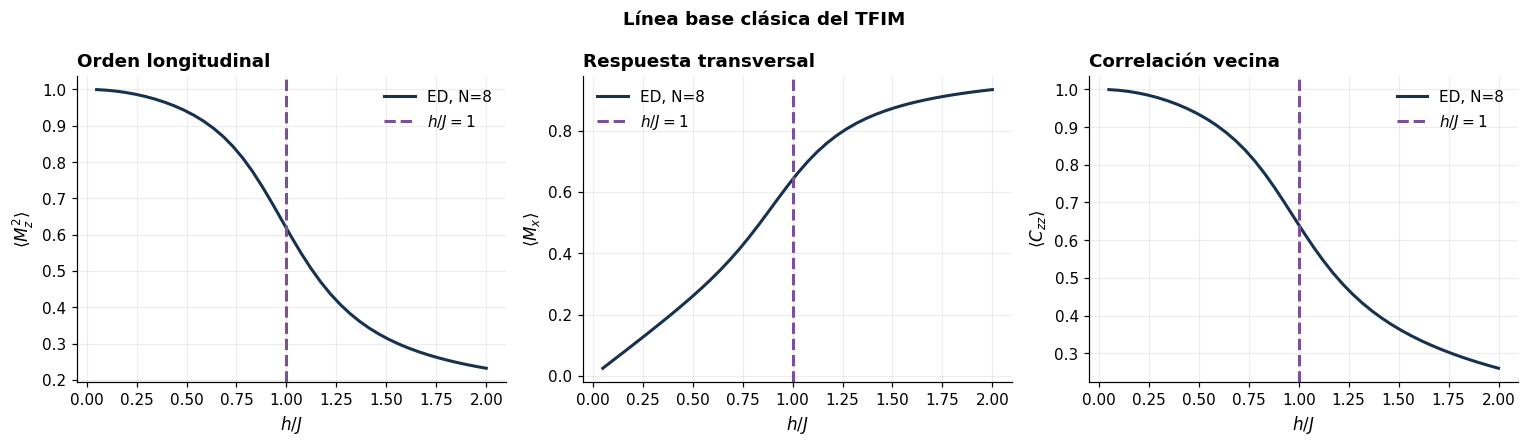

In [4]:
h_barrido = np.linspace(0.05, 2.0, 41)
baseline_ed = barrido_estado_base_tfim(
    n_q=N_BASELINE,
    valores_h_sobre_J=h_barrido,
    J=J,
    periodic=PERIODIC,
)
graficar_linea_base(baseline_ed, N_BASELINE)

In [5]:
baseline_reto = barrido_estado_base_tfim(
    n_q=N_BASELINE,
    valores_h_sobre_J=RAZONES_RETO,
    J=J,
    periodic=PERIODIC,
)
filas_baseline = [
    (
        razon,
        baseline_reto["energia_por_sitio"][i],
        baseline_reto["mz"][i],
        baseline_reto["mz2"][i],
        baseline_reto["mx"][i],
        baseline_reto["czz"][i],
    )
    for i, razon in enumerate(RAZONES_RETO)
]
display(Markdown(tabla_markdown(
    ["h/J", "E0/N", "<Mz>", "<Mz²>", "<Mx>", "<Czz>"],
    filas_baseline,
)))

| h/J | E0/N | <Mz> | <Mz²> | <Mx> | <Czz> |
| --- | --- | --- | --- | --- | --- |
| 0.50000 | -1.06364 | -0.00000 | 0.93955 | 0.26006 | 0.93360 |
| 1.00000 | -1.28146 | -0.00000 | 0.61752 | 0.64073 | 0.64073 |
| 2.00000 | -2.12727 | 0.00000 | 0.23227 | 0.93360 | 0.26006 |

**Lectura física.** Al aumentar $h/J$, $\langle M_z^2\rangle$ y
$\langle C_{zz}\rangle$ disminuyen mientras $\langle M_x\rangle$ crece. La
competencia se concentra alrededor de $h/J\approx1$. El valor casi nulo de
$\langle M_z\rangle$ en el estado base finito es una consecuencia de simetría,
no ausencia automática de orden.

## 4. Dinámica: Trotter frente a ED

La cadena de $N=6$ parte de $|00\cdots0\rangle$. Comparamos los mismos tiempos,
parámetros y condiciones de frontera para evitar una comparación artificial.

(<Figure size 1540x440 with 3 Axes>,
 array([<Axes: title={'left': 'Ferromagnético · h/J=0.5'}, xlabel='$Jt$', ylabel='$\\langle M_z\\rangle$'>,
        <Axes: title={'left': 'Cercano al crítico · h/J=1'}, xlabel='$Jt$', ylabel='$\\langle M_z\\rangle$'>,
        <Axes: title={'left': 'Paramagnético · h/J=2'}, xlabel='$Jt$', ylabel='$\\langle M_z\\rangle$'>],
       dtype=object))

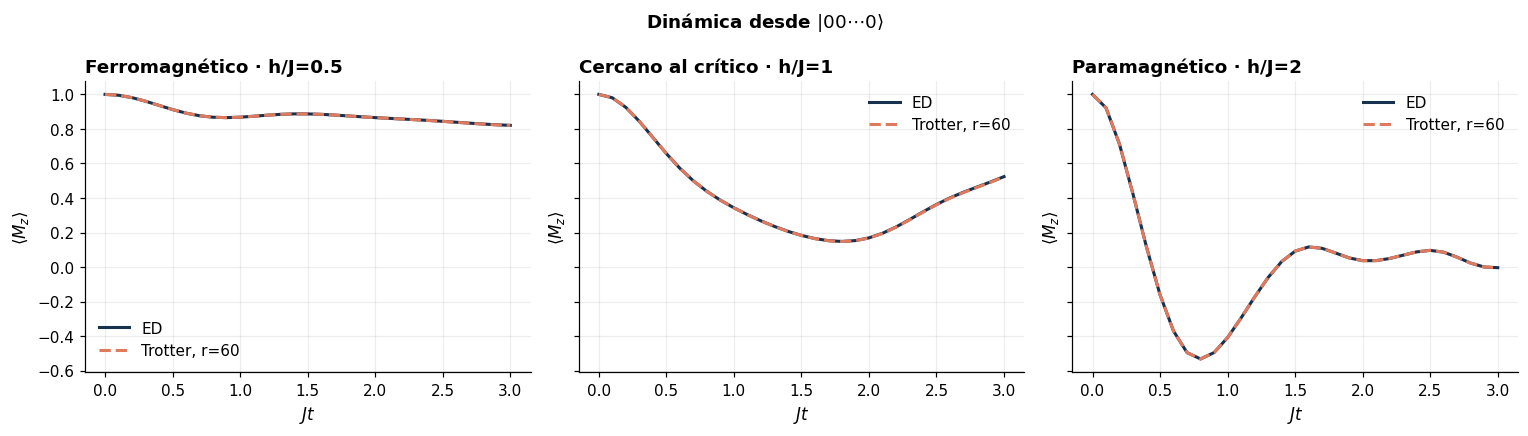

In [6]:
etiquetas = {
    "Ferromagnético · h/J=0.5": 0.5,
    "Cercano al crítico · h/J=1": 1.0,
    "Paramagnético · h/J=2": 2.0,
}
dinamicas = {
    etiqueta: dinamica_tfim(
        J=J,
        h=razon * J,
        n_q=N_DINAMICA,
        tiempos=TIEMPOS,
        r=PASOS_TROTTER,
        periodic=PERIODIC,
    )
    for etiqueta, razon in etiquetas.items()
}
graficar_dinamica_comparada(
    dinamicas, "mz", r"$\langle M_z\rangle$"
)

(<Figure size 1540x440 with 3 Axes>,
 array([<Axes: title={'left': 'Ferromagnético · h/J=0.5'}, xlabel='$Jt$', ylabel='$\\langle C_{zz}\\rangle$'>,
        <Axes: title={'left': 'Cercano al crítico · h/J=1'}, xlabel='$Jt$', ylabel='$\\langle C_{zz}\\rangle$'>,
        <Axes: title={'left': 'Paramagnético · h/J=2'}, xlabel='$Jt$', ylabel='$\\langle C_{zz}\\rangle$'>],
       dtype=object))

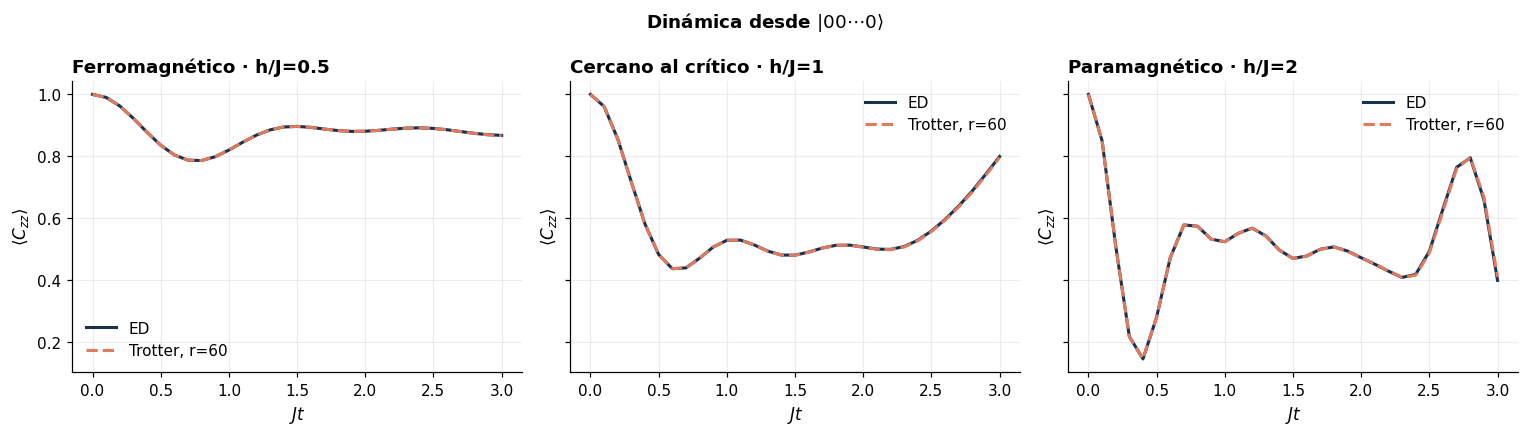

In [7]:
graficar_dinamica_comparada(
    dinamicas, "czz", r"$\langle C_{zz}\rangle$"
)

In [8]:
filas_error = []
for etiqueta, datos in dinamicas.items():
    razon = datos["h"] / datos["J"]
    error_mz = np.max(np.abs(datos["mz_trotter"] - datos["mz_exacta"]))
    error_czz = np.max(np.abs(datos["czz_trotter"] - datos["czz_exacta"]))
    peor_infidelidad = np.max(1.0 - datos["fidelidad"])
    filas_error.append((razon, error_mz, error_czz, peor_infidelidad))

display(Markdown(tabla_markdown(
    ["h/J", "max |ΔMz|", "max |ΔCzz|", "max (1-F)"],
    filas_error,
)))

| h/J | max |ΔMz| | max |ΔCzz| | max (1-F) |
| --- | --- | --- | --- |
| 0.50000 | 0.00058 | 0.00044 | 0.00189 |
| 1.00000 | 0.00203 | 0.00337 | 0.00306 |
| 2.00000 | 0.00037 | 0.01157 | 0.00545 |

Las curvas muestran tres ritmos de dinámica distintos. El error no depende
sólo del número de qubits: también crece con el tiempo total y con la
no-conmutatividad efectiva de los términos. Por eso el siguiente chequeo varía
$\Delta t$ de forma controlada.

## 5. Error de Trotter y prueba de convergencia

Repetimos la instancia crítica $N=6$, $h/J=1$, $Jt=1$ con distintos números de
pasos. Reducir $\Delta t$ debe disminuir tanto la infidelidad como el error de
los observables.

(<Figure size 1155x440 with 2 Axes>,
 array([<Axes: title={'left': 'Error de estado'}, xlabel='$\\Delta t$', ylabel='$1-F$'>,
        <Axes: title={'left': 'Peor error observable'}, xlabel='$\\Delta t$', ylabel='error absoluto'>],
       dtype=object))

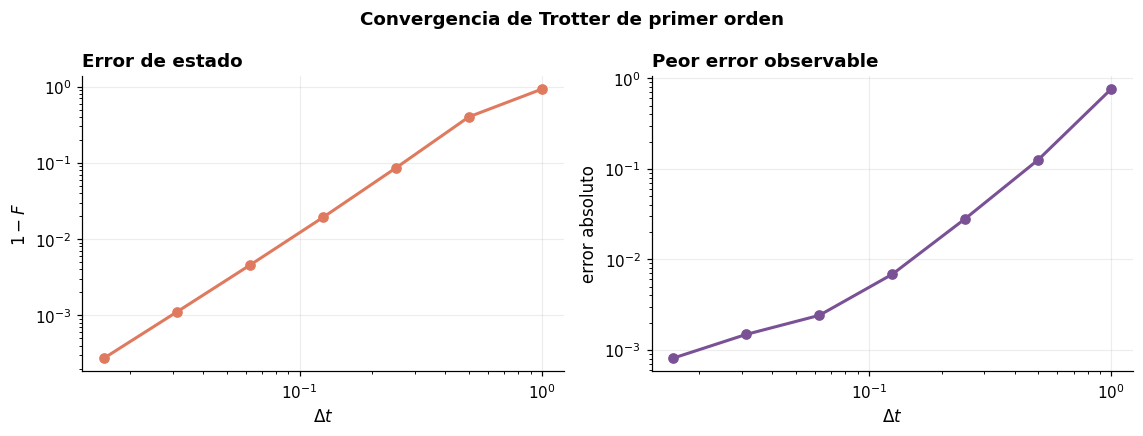

In [9]:
convergencia = analisis_convergencia_trotter(
    n_q=N_DINAMICA,
    valores_r=(1, 2, 4, 8, 16, 32, 64),
    t=1.0,
    J=J,
    h=J,
    periodic=PERIODIC,
)
graficar_convergencia(convergencia)

In [10]:
filas_convergencia = zip(
    convergencia["r"],
    convergencia["dt"],
    convergencia["fidelidad"],
    convergencia["error_max_observable"],
)
display(Markdown(tabla_markdown(
    ["r", "Δt", "F", "peor error observable"],
    list(filas_convergencia),
)))

| r | Δt | F | peor error observable |
| --- | --- | --- | --- |
| 1 | 1.00000 | 0.07312 | 0.75949 |
| 2 | 0.50000 | 0.59903 | 0.12571 |
| 4 | 0.25000 | 0.91418 | 0.02813 |
| 8 | 0.12500 | 0.98076 | 0.00685 |
| 16 | 0.06250 | 0.99544 | 0.00241 |
| 32 | 0.03125 | 0.99889 | 0.00148 |
| 64 | 0.01562 | 0.99973 | 0.00081 |

## 6. ¿Se degrada al aumentar el sistema?

Conservamos $r=10$, $Jt=1$ y $h/J=1$ para $N=4,6,8$. La comparación separa dos
efectos: la fidelidad del estado y el crecimiento determinista del circuito.
ED sigue siendo viable aquí, pero su matriz tiene dimensión $2^N\times2^N$.

(<Figure size 924x495 with 2 Axes>,
 (<Axes: title={'left': 'Calidad vs. tamaño'}, xlabel='qubits N', ylabel='fidelidad'>,
  <Axes: ylabel='número de compuertas'>))

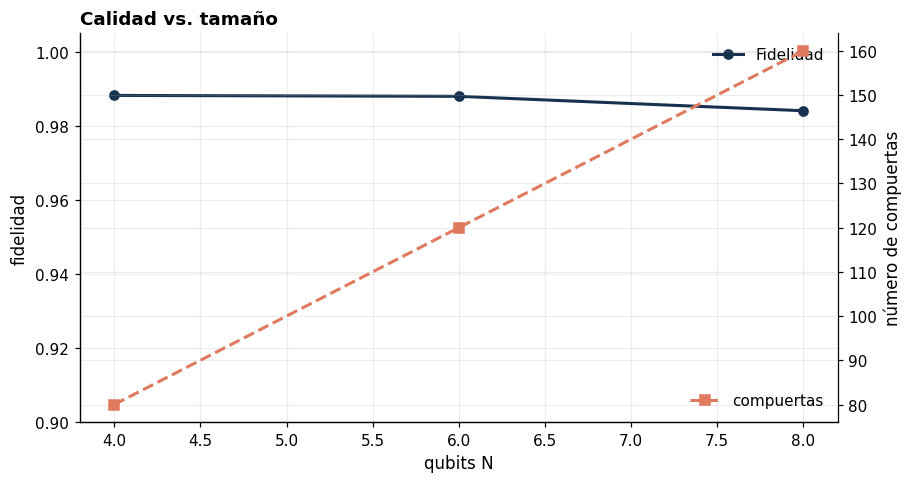

In [11]:
escalado = analisis_escalado_tfim(
    tamanos=(4, 6, 8),
    r=10,
    t=1.0,
    J=J,
    h=J,
    periodic=PERIODIC,
)
graficar_escalado(escalado)

In [12]:
filas_escalado = zip(
    escalado["n_q"],
    escalado["fidelidad"],
    escalado["profundidad"],
    escalado["compuertas"],
)
display(Markdown(tabla_markdown(
    ["N", "F", "profundidad", "compuertas"],
    list(filas_escalado),
)))

| N | F | profundidad | compuertas |
| --- | --- | --- | --- |
| 4 | 0.98820 | 50 | 80 |
| 6 | 0.98795 | 70 | 120 |
| 8 | 0.98406 | 90 | 160 |

**Conclusión del núcleo.** Para estos tamaños y simulación ideal, Trotter
reproduce cualitativamente la dinámica y converge al reducir $\Delta t$. La
calidad baja de forma moderada al crecer $N$ con $r$ fijo, mientras el número de
compuertas aumenta. Esto no demuestra ventaja cuántica: ED es la referencia
más fuerte para estas instancias pequeñas.

## 7. Extensión opcional: Fermi–Hubbard 1D

El enunciado propone Fermi–Hubbard 2D como extensión. El código disponible en
el repositorio implementa, por ahora, una **cadena abierta 1D** mediante
Jordan–Wigner y Trotter de primer orden. Se conserva sin presentarlo como
resultado 2D.

Para una demostración ligera usamos cuatro sitios ($8$ modos/qubits),
$U/t=4$ y semillenado. Verificamos densidad, doble ocupación y conservación del
número total de partículas.

(<Figure size 1540x440 with 3 Axes>,
 array([<Axes: title={'left': 'Densidad local'}, xlabel='$t$', ylabel='$\\langle n_i\\rangle$'>,
        <Axes: title={'left': 'Doble ocupación'}, xlabel='$t$', ylabel='$\\langle n_{\\uparrow}n_{\\downarrow}\\rangle$'>,
        <Axes: title={'left': 'Chequeo de conservación'}, xlabel='$t$', ylabel='$\\langle N\\rangle$'>],
       dtype=object))

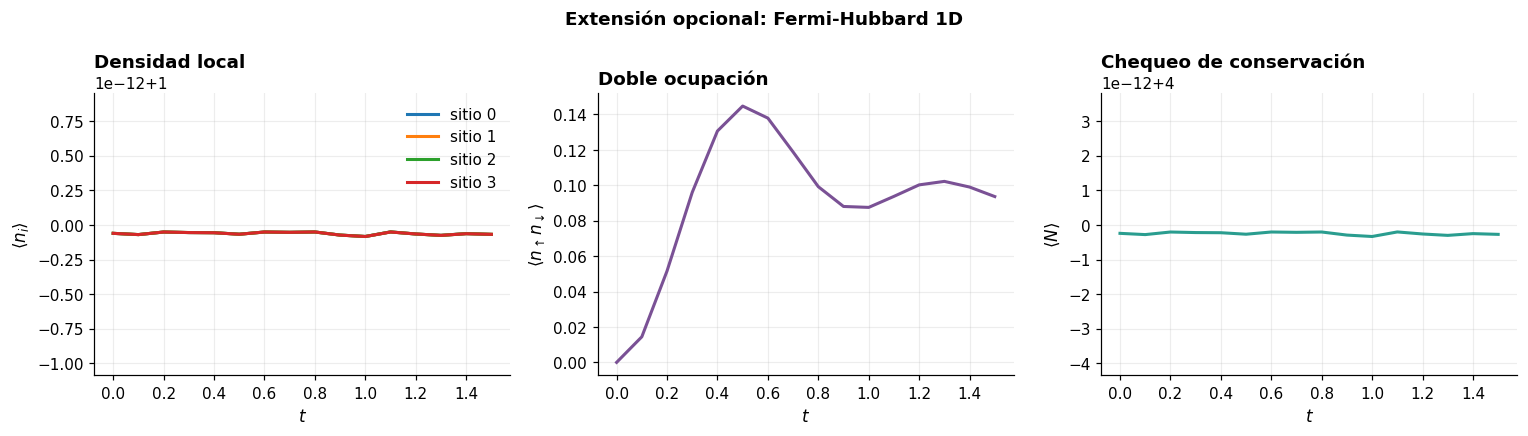

In [13]:
tiempos_fh = np.linspace(0.0, 1.5, 16)
datos_fh = evolucion_fermi_hubbard_observables(
    hop=1.0,
    U=4.0,
    n_q=8,
    r=8,
    tiempos=tiempos_fh,
    occupied_modes=(0, 3, 4, 7),
)
graficar_fermi_hubbard(datos_fh)

In [14]:
desviacion_particulas = np.max(
    np.abs(datos_fh["numero_particulas"] - datos_fh["numero_particulas"][0])
)
display(Markdown(
    f"**Chequeo numérico:** $N(0)={datos_fh['numero_particulas'][0]:.6f}$, "
    f"máxima desviación $={desviacion_particulas:.3e}$."
))

**Chequeo numérico:** $N(0)=4.000000$, máxima desviación $=9.104e-14$.

## 8. VQE y Guppy: estado de la implementación

- `funciones_pennylane.py` conserva el Hamiltoniano, ansatz, VQE y barrido de
  campos construidos en el notebook de implementación.
- `funciones_guppy.py` conserva el prototipo de dos qubits basado en conteos.
- No se mezclan estos backends con el núcleo porque el kernel reproducible
  actual contiene Qiskit pero no PennyLane/Guppy.
- El prototipo Guppy sigue siendo exploratorio; no se reportan sus números como
  resultados validados.

In [15]:
estado_backends = {
    "PennyLane disponible en este kernel": find_spec("pennylane") is not None,
    "Guppy disponible en este kernel": find_spec("guppylang") is not None,
}
estado_backends

{'PennyLane disponible en este kernel': True,
 'Guppy disponible en este kernel': True}

## 9. Limitaciones honestas

- Los resultados TFIM y Fermi–Hubbard son de vector de estado ideal: no
  incluyen shots, ruido, conectividad, compilación a H2 ni mitigación.
- La transición en $h/J=1$ es exacta en el límite termodinámico; $N=6$ y $N=8$
  presentan redondeo de tamaño finito.
- La fidelidad es accesible en simulación, pero no es un observable directo y
  barato en hardware.
- ED escala exponencialmente y limita el benchmarking, pero sigue siendo el
  método apropiado para las instancias estudiadas aquí.
- La extensión Fermi–Hubbard es 1D y pequeña; no satisface todavía la opción 2D
  del enunciado.
- VQE y Guppy están preservados como trabajo opcional, no como evidencia de
  ejecución validada en este notebook.

## 10. Conexión con los ODS

El aporte directo de este trabajo es metodológico: TFIM funciona como banco de
pruebas de fidelidad y costo para simuladores cuánticos. Una simulación más
confiable de sistemas correlacionados puede apoyar, a largo plazo:

- **ODS 7:** comprensión de fases y materiales relevantes para transmisión y
  almacenamiento energético.
- **ODS 9:** desarrollo de herramientas de simulación como infraestructura
  científica.
- **ODS 12:** búsqueda computacional más dirigida y potencial reducción de
  ciclos experimentales de materiales.
- **ODS 13:** exploración de materiales para energía limpia y captura de
  carbono.

La cadena causal es indirecta: **mejor validación algorítmica → simulaciones de
materiales más confiables → mejor selección de candidatos experimentales**.
No atribuimos un impacto material real a estas instancias pequeñas.

## 11. Lista de verificación de la entrega

- [x] Hamiltoniano TFIM documentado.
- [x] Circuito Trotter y tamaño de paso explícitos.
- [x] Magnetización y correlación para $h/J=\{0.5,1.0,2.0\}$.
- [x] Línea base ED para $N=8$ y comparación dinámica para $N=6$.
- [x] Convergencia al reducir $\Delta t$.
- [x] Escalado en tres tamaños.
- [x] Figuras reproducibles desde un único notebook.
- [x] Funciones voluminosas extraídas de los notebooks.
- [x] Limitaciones y estado de extensiones declarados.
- [ ] Ejecución en H2, barras de error por shots y mitigación de ruido.
- [ ] Fermi–Hubbard 2D.

## Referencias

1. M. Suzuki, “Generalized Trotter's formula and systematic approximants of
   exponential operators and inner derivations with applications to many-body
   problems”, *Communications in Mathematical Physics* **51**, 183–190 (1976).
2. S. Ebadi *et al.*, “Quantum phases of matter on a 256-atom programmable
   quantum simulator”, *Nature* **595**, 227–232 (2021).
3. S. Sachdev, *Quantum Phase Transitions*, Cambridge University Press.